# Ferroelectric Arbitrary Waveform Testing

Three constant-voltage segments followed by an oscillating segment, using `ArbWaveform`. Virtual instruments are selected by default.

### Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from piec.drivers.awg.virtual_awg import VirtualAwg
from piec.drivers.oscilloscope.virtual_oscilloscope import VirtualScope
from piec.drivers.autodetect import autodetect
from piec.measurement.discrete_waveform import ArbWaveform
from piec.analysis.utilities import standard_csv_to_metadata_and_data

The Digilent/MCC driver cannot be used without this library.


### Instrument Setup

In [2]:
awg = VirtualAwg("VIRTUAL")
osc = VirtualScope("VIRTUAL")

# Replace the virtual instruments with connected instruments if needed.
awg = autodetect("awg")
osc = autodetect('GPIB0::7::INSTR')

print("AWG:", awg.idn())
print("OSC:", osc.idn())

Autodetect: Loaded piec.drivers.awg.k_81150a.Keysight81150a for instrument at GPIB0::8::INSTR
Autodetect: Loaded piec.drivers.oscilloscope.k_dsox3024a.KeysightDSOX3024a for instrument at GPIB0::7::INSTR
AWG: Agilent Technologies,81150A,MY53821602,3.0.0.0-4.6

OSC: AGILENT TECHNOLOGIES,DSO-X 3024A,MY63080078,02.65.2021030741



### Waveform Definition

Times are in seconds, frequencies in Hz, and voltages in V. `vamp` is the peak amplitude about `vdcoffset`; `fwave` applies only to the oscillating segment. The full sequence repeats at `1 / (t0 + t1 + t2 + twave)`.

In [47]:
path = Path("//files22.brown.edu/Research/ENG_Caretta_Shared/Group/probe_station/AQ_047/091026/arb")
voltage_scale = 0.005 #[what's the minimum voltage scale for the oscilloscope?]
voltage_channel = "1"

dt_out = 5e-9 #[s/output sample]
fsample = 1/dt_out 
t0 = 5e1*dt_out
t1 = 5e1*dt_out
t2 = 5e1*dt_out
twave = 4*5e1*dt_out

v0 = 1.5
v1 = 0.0
v2 = 1.5
vdcoffset = 0.0
vamp = 1.0
fwave = 2/twave
wavestr = "triangle"  # sine, square, sawtooth, triangle

In [49]:
if fsample <= 0 or min(t0, t1, t2, twave) < 0:
    raise ValueError("Use a positive sample rate and nonnegative durations.")

ttot = t0 + t1 + t2 + twave
if ttot <= 0:
    raise ValueError("The total waveform duration must be positive.")

Nsample_mult = 1
Nsample = round( Nsample_mult *ttot * fsample)

tvec = np.linspace(0, ttot, Nsample, endpoint=False)
if not 2 <= Nsample <= 524_288:
    raise ValueError(f"{Nsample} points outside 2 and 524,288 waveform points.")
if Nsample / ttot > 1e9:
    raise ValueError(f"The sample rate {Nsample / ttot:.2e} Sa/s must be less than 1 GHz.")

#tvec = np.arange(0, ttot, 1 / fsample) #original
#if not 2 <= len(tvec) <= 100_000:
    #raise ValueError("Use between 2 and 100,000 waveform points.")

t_start_wave = t0 + t1 + t2
vvec = np.zeros_like(tvec)
vvec[(tvec >= 0) & (tvec < t0)] = v0
vvec[(tvec >= t0) & (tvec < t0 + t1)] = v1
vvec[(tvec >= t0 + t1) & (tvec < t_start_wave)] = v2

idxwave = tvec >= t_start_wave
t_rel = tvec[idxwave] - t_start_wave

if wavestr == "sine":
    vvec[idxwave] = vdcoffset + vamp * np.sin(2 * np.pi * fwave * t_rel)
elif wavestr == "square":
    vvec[idxwave] = vdcoffset + vamp * np.sign(np.sin(2 * np.pi * fwave * t_rel))
elif wavestr == "sawtooth":
    vvec[idxwave] = vdcoffset + vamp * (2 * ((t_rel * fwave) % 1.0) - 1)
elif wavestr == "triangle":
    vvec[idxwave] = vdcoffset + vamp * (1 - 2 * np.abs(2 * ((t_rel * fwave) % 1.0) - 1))
else:
    raise ValueError(f"Unknown wavestr: {wavestr}")

cycle_freq = 1.0 / ttot
print(f"{len(vvec)} points, {cycle_freq:g} Hz repetition frequency")

350 points, 571429 Hz repetition frequency


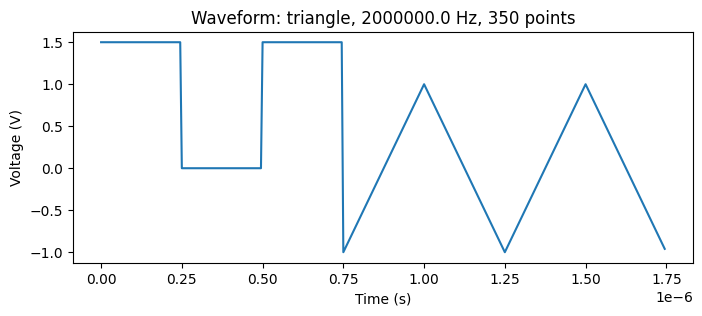

In [50]:
title_string = f"Waveform: {wavestr}, {fwave} Hz, {len(vvec)} points"
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tvec, vvec)
ax.set(xlabel="Time (s)", ylabel="Voltage (V)", title=title_string)
plt.show()

### Run

In [51]:
experiment = ArbWaveform(
    voltage_array=vvec,
    frequency=cycle_freq,
    awg=awg,
    osc=osc,
    v_div=voltage_scale,
    voltage_channel=voltage_channel,
    save_dir=str(path),
)
experiment.run_experiment()

Running experiment for arb_waveform measurement...
Oscilloscope configured.
AWG initialized.
Estimated Peak-to-Peak Ratio of targeted value is 100.0%
AWG configured.
Capturing waveform of type arb_waveform for 1.7499999999999998e-06 seconds...
Waveform captured.
Waveform applied and captured.
Waveform data saved to \\files22.brown.edu\Research\ENG_Caretta_Shared\Group\probe_station\AQ_047\091026\arb\0_arb_waveform_350pts_571429Hz.csv
Waveform saved.
Analysis method not defined. Not changing \\files22.brown.edu\Research\ENG_Caretta_Shared\Group\probe_station\AQ_047\091026\arb\0_arb_waveform_350pts_571429Hz.csv
Analysis complete.
Experiment complete.


### Captured Response

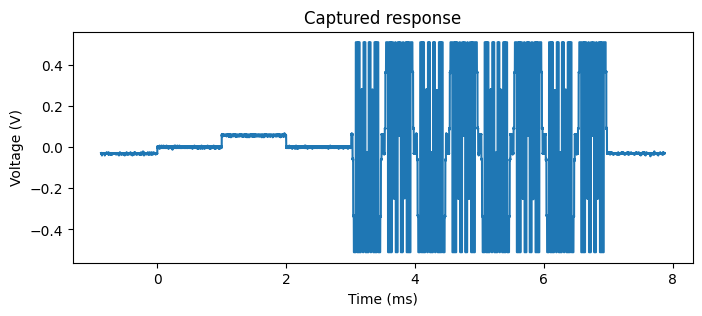

In [20]:
metadata, data = standard_csv_to_metadata_and_data(experiment.filename)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(data["time (s)"] * 1e3, data["voltage (V)"])
ax.set(xlabel="Time (ms)", ylabel="Voltage (V)", title="Captured response")
plt.show()